# Spatial deconvolution with RCTD

**RCTD** (Robust Cell Type Decomposition, [Cable et al., *Nat. Biotechnol.* 2022](https://doi.org/10.1038/s41587-021-00830-w)) is the deconvolution method 10x Genomics officially recommends for Visium / Visium HD spot decomposition. The original implementation (`spacexr`) is in R; this notebook uses the pure-Python port [`rctd-py`](https://github.com/p-gueguen/rctd-py).

RCTD is wired through the same `ov.space.Deconvolution` class that already wraps Tangram and cell2location, so the API is identical to the other deconvolution backends — the only thing you change is `method='RCTD'`.

We exercise it on the **same Lymph Node dataset** used by the canonical `t_decov` tutorial, both loaded through omicverse helpers (no scanpy):

- `ov.datasets.sc_ref_Lymph_Node()` — Lymph Node scRNA-seq reference (annotated by `Subset`)
- `ov.datasets.visium_lymph_node()` — 10x V1 Human Lymph Node Visium (downloads from the public 10x CDN on first call, then cached locally)

so the cell-type proportions can be compared directly against Tangram / cell2location runs in the existing tutorial.

## Environment setup

In [1]:
import omicverse as ov
ov.style(font_path='Arial')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format='png'  # avoid retina; large H&E + pies overflow matplotlib PNG buffer


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Step 1: Prepare the scRNA-seq reference

RCTD trains a per-cell-type expression profile from the scRNA-seq reference and uses it to fit each spatial pixel. The reference must contain **raw counts** in either `adata.X` or `adata.layers['counts']` — RCTD's likelihood model is defined over count data, not log-normalised values.

`ov.datasets.sc_ref_Lymph_Node()` ships counts in `layers['counts']`, so the integration picks them up automatically (and falls back to `.X` when the layer isn't present).

In [2]:
adata_sc = ov.datasets.sc_ref_Lymph_Node()
print(adata_sc)
print()
print('cell types:', adata_sc.obs['Subset'].nunique())
print("counts layer present:", 'counts' in adata_sc.layers)

🧬 Loading SC reference data for Lymph Node
⚠️ File ./data/sc_ref_Lymph_Node.h5ad already exists
 Loading data from ./data/sc_ref_Lymph_Node.h5ad


✅ Successfully loaded: 73260 cells × 10237 genes
AnnData object with n_obs × n_vars = 73260 × 10237
    obs: 'Age', 'BCELL_CLONE', 'BCELL_CLONE_SIZE', 'Donor', 'ID', 'IGH_MU_FREQ', 'ISOTYPE', 'LibraryID', 'Method', 'Population', 'PrelimCellType', 'Sample', 'Sex', 'Study', 'Tissue', 'barcode', 'batch', 'doublet_score', 'index', 'predicted_doublet', 'percent_mito', 'n_counts', 'n_genes', 'S_score', 'G2M_score', 'phase', 'VDJsum', 'cell_cycle_diff', 'PrelimCellType_new', 'leiden', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'CellType', 'CellType2', 'Subset', 'Subset_Broad', 'Subset_all', 'new_celltype', 'Subset_int', 'Subset_print'
    var: 'GeneID-2', 'GeneName-2', 'feature_types', 'feature_types-0', 'feature_types-1', 'gene_ids-1', 'gene_ids-4861STDY7135913-0', 'gene_ids-4861STDY7135914-0', 'gene_ids-4861STDY7208412-0', 'gene_ids-4861STDY7208413-0', 'gene_ids-Human_colon_16S7255677-0', 'gene_ids-Human_colon_16S7255678-0', 'gene_ids-Human_colon_16S8000484-0', 'gene_ids-Pan_T7935494-0

## Step 2: Prepare the spatial transcriptomics dataset

`ov.datasets.visium_lymph_node()` downloads the public 10x V1 Human Lymph Node sample (filtered count matrix + spatial tarball) and reads it through `ov.io.spatial.read_visium`. Raw counts land directly in `.X`, which is what RCTD wants.

In [3]:
adata_sp = ov.datasets.visium_lymph_node()
adata_sp.obs['sample'] = list(adata_sp.uns['spatial'].keys())[0]
if 'counts' not in adata_sp.layers:
    adata_sp.layers['counts'] = adata_sp.X.copy()
print(adata_sp)


🧬 Loading 10x V1 Human Lymph Node Visium data
[Visium] Reading Visium data from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/V1_Human_Lymph_Node
[Visium] Loading count matrix: filtered_feature_bc_matrix.h5


[Visium] Library ID: V1_Human_Lymph_Node
[Visium] Loading tissue positions: tissue_positions_list.csv
[Visium] Loading images and scale factors
[Visium] Done (n_obs=4035, n_vars=36601)


AnnData object with n_obs × n_vars = 4035 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'


## Step 3: Run RCTD

Construct the `Deconvolution` object exactly like for Tangram / cell2location and pass `method='RCTD'`.

**Important note on preprocessing:** unlike the Tangram / cell2location flow, **we do not call `preprocess_sc` / `preprocess_sp`** before RCTD. Those helpers replace `.X` with log-normalised values and subset to HVGs / SVGs — but RCTD's likelihood model wants raw counts and selects its own informative gene set internally (the `gene_cutoff` / `fc_cutoff` controls in `RCTDConfig`). The integration pulls raw counts from `layers['counts']` if present, otherwise from `.X`.

**Mode choice:** the rctd-py paper default `mode='doublet'` (each pixel = at most 2 cell types) matches the biology of a 55µm Visium spot and runs ≈4× faster than `'full'`. The omicverse integration scatters doublet weights into the canonical `adata_cell2location` per-cell-type proportion matrix, so downstream visualisation is identical to the other backends.

**Tutorial speed:** `sigma_override=84` skips the auto-calibration step (≈14 min on its own for this slide; `84` ≈ sigma_c=0.84 gives results bit-identical to R spacexr per the rctd-py docs), and `config={'compile': False}` skips torch.compile JIT (eager mode wins for one-off runs). Total RCTD wall-clock with these settings: ~2 min on a single GPU.


In [4]:
decov_obj = ov.space.Deconvolution(
    adata_sc=adata_sc,
    adata_sp=adata_sp,
)

✓ Existing 'counts' layer in spatial transcriptomics data


In [5]:
decov_obj.deconvolution(
    method='RCTD',
    celltype_key_sc='Subset',
    rctd_kwargs={
        # `mode='doublet'` is the rctd-py / R-spacexr paper default for
        # spot-level Visium and is what 10x recommends. It assumes each
        # pixel comes from at most 2 cell types — closer to the biology
        # of a 55µm Visium spot — and is also the fastest mode
        # (≈4× faster than 'full' on this dataset). The omicverse
        # integration scatters the doublet weights back into a per-
        # cell-type proportion matrix on `adata_cell2location.X`, so
        # the same downstream visualisations work either way.
        'mode': 'doublet',
        'cell_min': 25,         # drop reference cell types with < cell_min cells
        'n_max_cells': 5000,    # tutorial-time subsample of the reference
        'min_UMI': 100,
        # `sigma_override=84` skips RCTD's auto sigma-calibration step
        # (this dataset's auto-calibration takes ~14 min on its own).
        # `84` ≈ sigma_c=0.84 — the value RCTD's authors recommend as
        # a starting point and what gives bit-identical results to R
        # spacexr per the rctd-py docs. Drop the override to re-enable
        # auto-calibration if you're running on a new tissue type.
        'sigma_override': 84,
        # batch_size: doublet mode enumerates C(K, 2) cell-type pairs
        # per pixel into a single tensor. With K=33 cell types and
        # 4035 spots the auto-default (200k spots/batch, sized for
        # VisiumHD-scale slides) blows past the GPU's memory budget.
        # 512 spots/batch fits comfortably and the per-batch overhead
        # is negligible at this slide size.
        'batch_size': 512,
        # `compile=False` disables torch.compile JIT — eager-mode is
        # the right choice for a single tutorial run; flip back to
        # the default `True` on production batch runs that share a
        # warm cache.
        'config': {
            'UMI_min': 100,
            'UMI_max': 20_000_000,
            'compile': False,
        },
    },
)


Running RCTD (mode='doublet') — this may take a while on full Visium slides.


UMI filter: kept 4033/4035 pixels (UMI range [100, 20000000])


Gene lists: bulk=3031, reg=1638 (from 10141 common)


Fitting bulk platform effects...


Using 1638 DE genes for pixel-level fitting


...

  [doublet] Step 1 done (821.6s)
  [doublet] Step 3: pairwise scoring (437462 triples)...


  [doublet] Step 3 done (19.9s)
  [doublet] Step 4: singlet scoring (60795 singles)...


  [doublet] Step 4 done (11.7s)
  [doublet] Step 5: classification (4033 pixels)...


  [doublet] Step 5 done (0.5s)
  [doublet] Step 6: final decomposition (4033 pixels)...


  [doublet] Step 6 done (0.2s)
  [doublet] Total doublet mode: 854.0s
✓ RCTD deconvolution is done
The deconvolution result is saved in self.adata_cell2location
Cell type proportions are also stored in self.adata_sp.obsm['rctd_proportions']
The full RCTD result object is saved in self.rctd_result


## Step 4: Inspect the result

`decov_obj.adata_cell2location` is the canonical omicverse output — a `(kept_pixels × n_cell_types)` AnnData of row-normalised proportions, with the spatial coordinates / `obsm` carried over from `adata_sp`. Same shape Tangram and cell2location populate, so all the downstream plotting in the existing `t_decov` tutorial works unchanged.

Two extras that are RCTD-specific:

- `decov_obj.rctd_result` — the raw `FullResult` / `DoubletResult` object from `rctd-py`, with the unnormalised `weights`, the `pixel_mask` (which pixels passed the UMI filter), and `converged` flags per pixel.
- `decov_obj.adata_sp.obsm['rctd_proportions']` — the same proportion matrix re-indexed back onto every pixel of the original `adata_sp` (filtered pixels get all-zero rows). Convenient for `ov.pl.spatial(color=<cell_type>)`.

In [6]:
decov_obj.adata_cell2location

AnnData object with n_obs × n_vars = 4033 × 33
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'sample'
    uns: 'spatial'
    obsm: 'spatial'

In [7]:
props = np.asarray(decov_obj.adata_cell2location.X)
print('row-sums (proportion check) min/max:', props.sum(axis=1).min(), props.sum(axis=1).max())
print('top cell types by mean proportion:')
ct_mean = decov_obj.adata_cell2location.X.mean(axis=0)
print(pd.Series(ct_mean, index=decov_obj.adata_cell2location.var_names)
        .sort_values(ascending=False).head(10))

row-sums (proportion check) min/max: 1.0 1.0
top cell types by mean proportion:
Macrophages_M1    0.264252
B_mem             0.151441
FDC               0.130530
B_naive           0.129809
Endo              0.095163
T_Treg            0.081916
T_CD4+_naive      0.052711
B_Cycling         0.029198
Macrophages_M2    0.028264
VSMC              0.009828
dtype: float32


## Step 5: Spatial visualisation

Re-using the same panel of canonical lymph-node markers as the `t_decov` tutorial so the RCTD output is directly comparable to the Tangram / cell2location results in that notebook.

Plotting: ['B_Cycling', 'B_GC_LZ', 'T_CD4+_TfH_GC', 'FDC', 'B_naive', 'T_CD4+_naive', 'B_plasma', 'Endo']


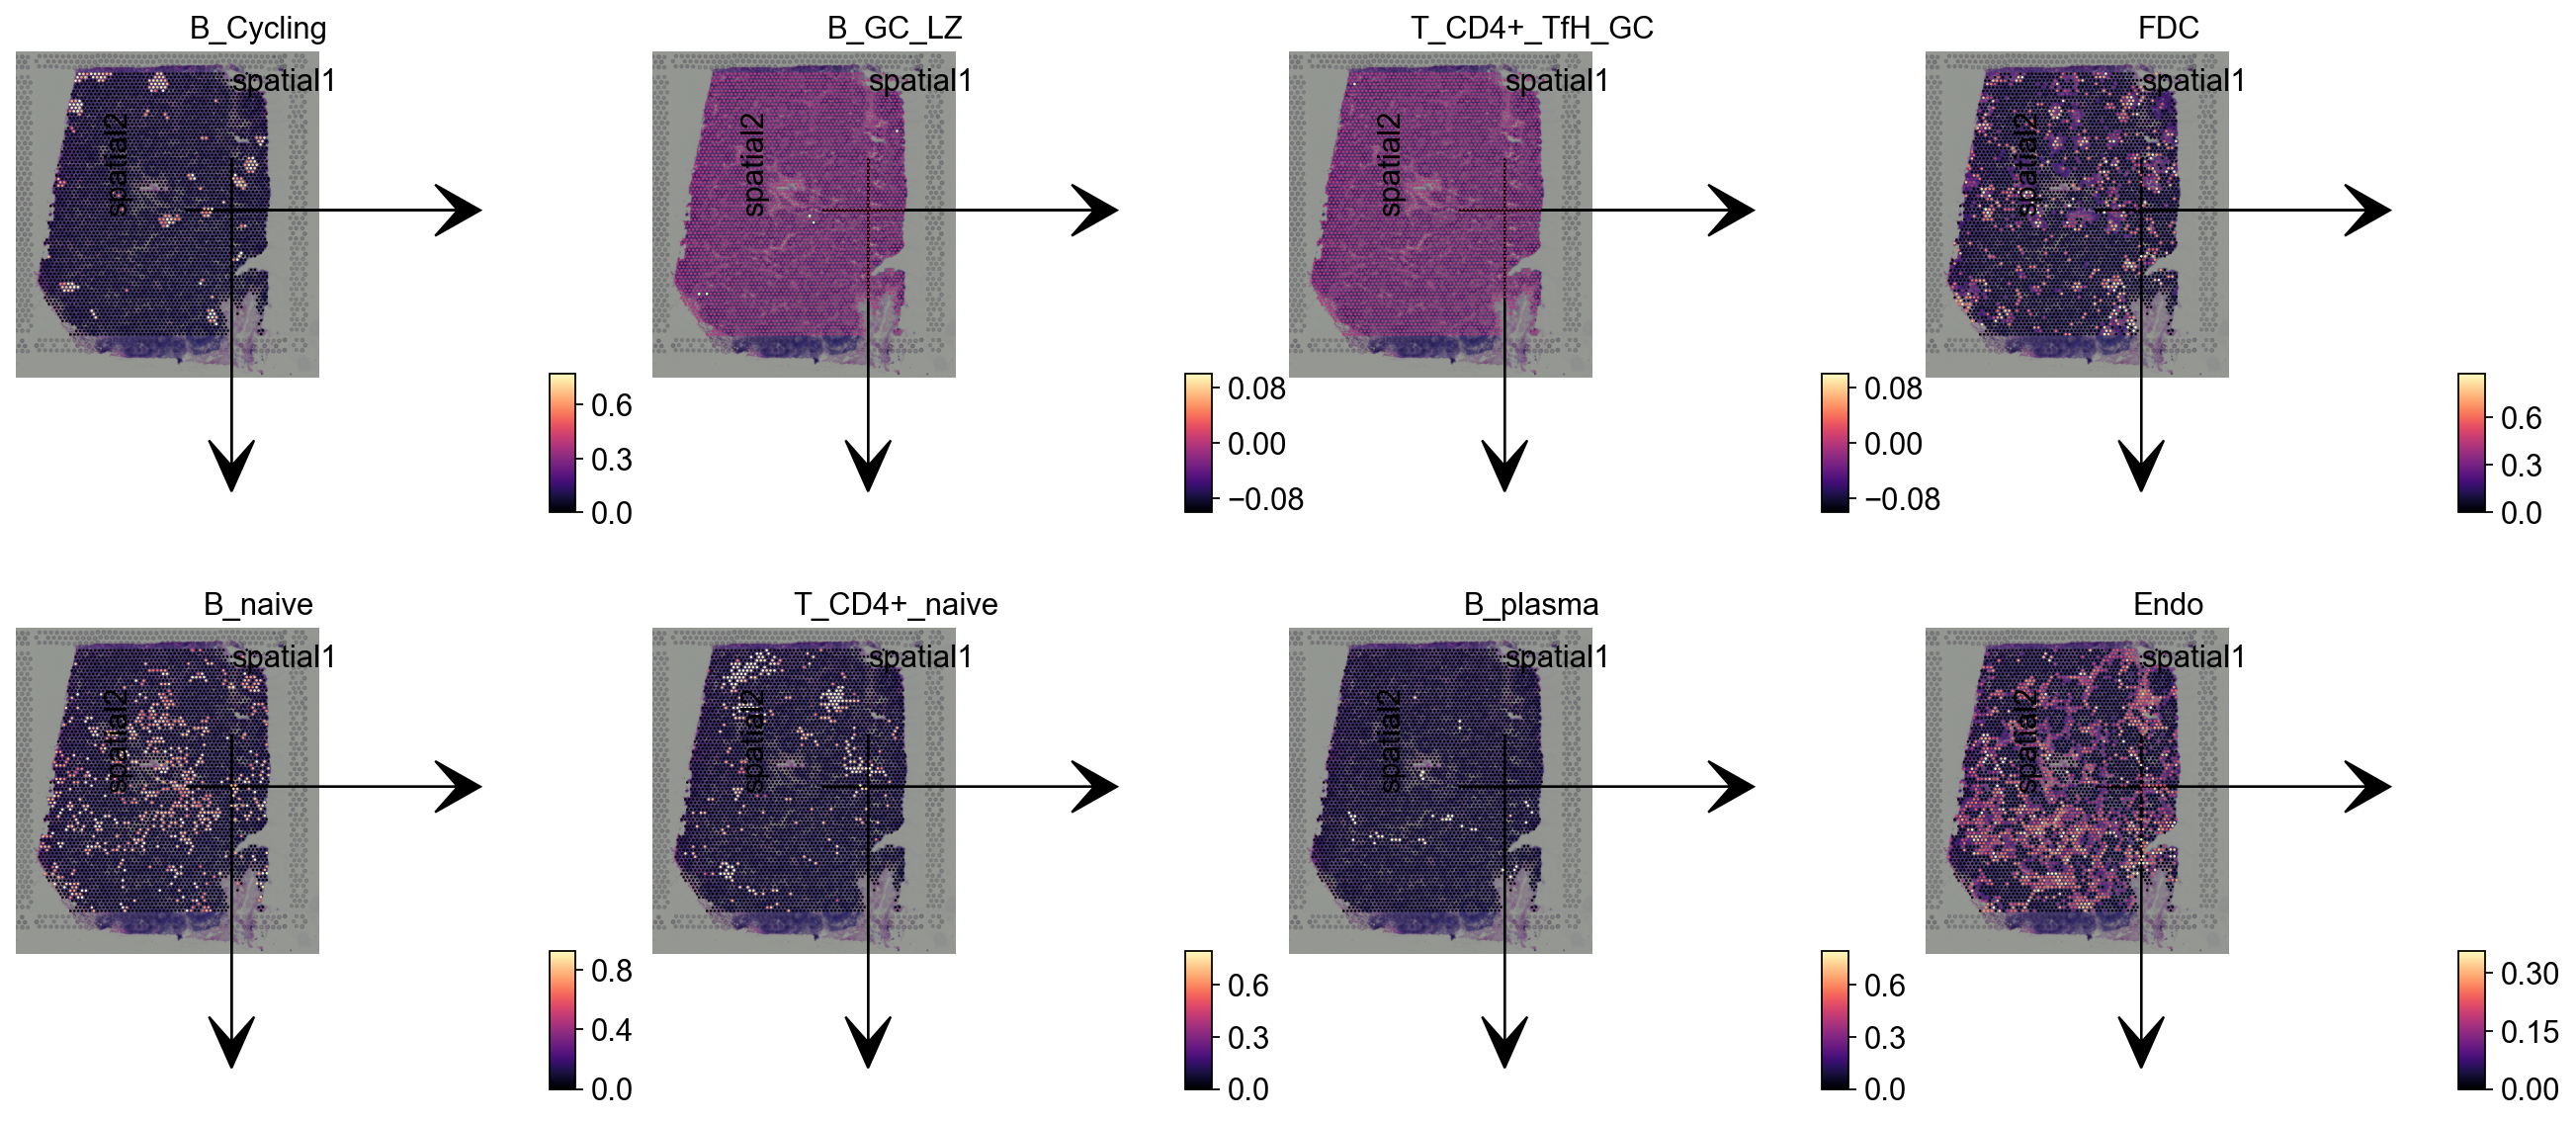

In [8]:
annotation_list = ['B_Cycling', 'B_GC_LZ', 'T_CD4+_TfH_GC', 'FDC',
                   'B_naive', 'T_CD4+_naive', 'B_plasma', 'Endo']
available = [a for a in annotation_list if a in decov_obj.adata_cell2location.var_names]
print('Plotting:', available)

ov.pl.spatial(
    decov_obj.adata_cell2location,
    color=available,
    cmap='magma',
    ncols=4,
    img_key='hires',
    vmin=0, vmax='p99.2',
    frameon=False,   # workaround: frameon='small' renders the axis arrow as a separate subplot per panel
)


### 5.2 Multi-cell-type overlay

RCTD's per-pixel proportion matrix can be drawn as an overlapping multi-channel image — one cell type per channel — to read out fine-grained tissue architecture (e.g. germinal-centre vs. naive-B regions in the lymph node).

In [9]:
color_dict = dict(zip(adata_sc.obs['Subset'].cat.categories,
                       adata_sc.uns['Subset_colors']))
clust_labels = available[:5]
clust_col = [str(c) for c in clust_labels]

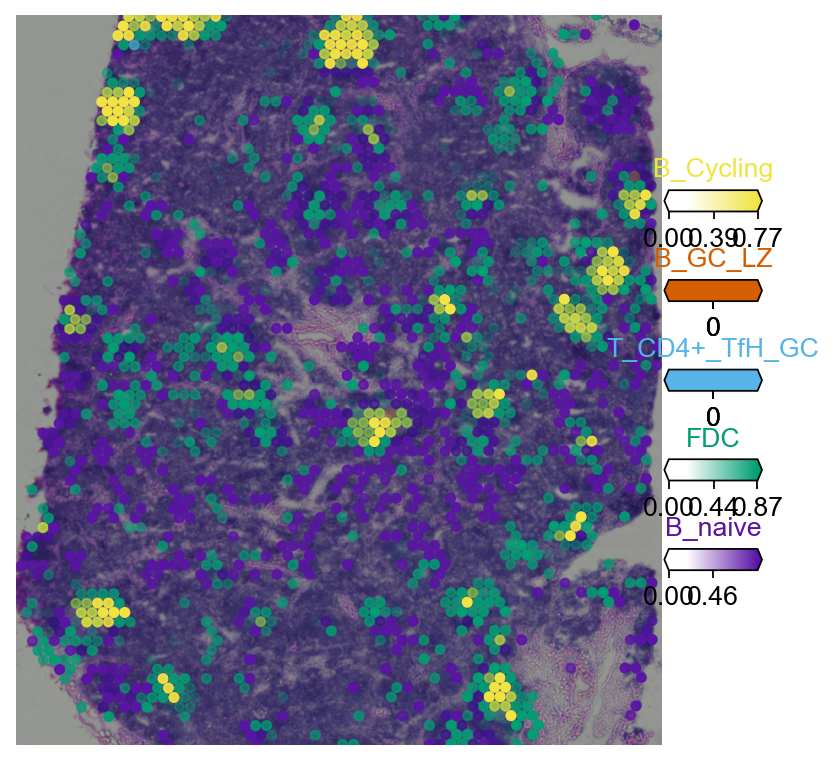

In [10]:
import matplotlib as mpl
with mpl.rc_context({'figure.figsize': (6, 6), 'axes.grid': False}):
    fig = ov.pl.plot_spatial(
        adata=decov_obj.adata_cell2location,
        color=clust_col,
        labels=clust_labels,
        show_img=True,
        style='fast',
        max_color_quantile=0.992,
        circle_diameter=4,
        colorbar_position='right',
    )

## Summary

We added RCTD as a new backend to `ov.space.Deconvolution`. The integration:

- accepts the same `(adata_sp, adata_sc)` constructor as Tangram / cell2location,
- automatically pulls raw counts from `adata.layers['counts']` (or falls back to `.X`),
- forwards every RCTD knob through `rctd_kwargs` (mode / cell_min / batch_size / sigma_override / a `config` dict for `RCTDConfig`),
- reshapes the `FullResult` / `DoubletResult` / `MultiResult` into the canonical `adata_cell2location` schema (pixels × cell-types proportion matrix, row-sums = 1),
- preserves the spatial `obsm` so all the existing visualisation helpers (`ov.pl.spatial`, `ov.space.crop_space_visium`, `ov.pl.plot_spatial`, `ov.pl.add_pie2spatial`) work unchanged.

Compared with the other backends already in the tutorial:

| Method | Speed (this dataset) | GPU? | Notes |
|---|---|---|---|
| Tangram | 15–30 min | yes | Mapping-based; needs HVG preprocessing |
| cell2location | 30–120 min | recommended | Bayesian; large `max_epochs`; needs HVG preprocessing |
| **RCTD** | **5–15 min** | yes (`device` in `RCTDConfig`) | **No SVG/HVG step**; uses raw counts directly |